In [7]:
from qiskit_nature.second_q.operators import FermionicOp
from qiskit_nature.second_q.mappers import JordanWignerMapper

epsilon = 0.0
gamma_0 = 1.0
U_0 = 0.0

num_sites = 6
num_spin_orbitals = 2*num_sites

terms = {}

for i in range(num_spin_orbitals):
    terms[f"+_{i} -_{i}"] = epsilon
hopping_pairs = [(i, (i+1) % 6) for i in range(num_sites)]
for i, j in hopping_pairs:
    i_up, i_down, j_up, j_down = i, num_sites+i, j, num_sites+j
    terms[f"+_{i_up} -_{j_up}"] = terms[f"+_{j_up} -_{i_up}"] = terms[f"+_{i_down} -_{j_down}"] = terms[f"+_{j_down} -_{i_down}"] = -gamma_0
for i in range(num_sites):
    up, down = i, num_sites+i
    terms[f"+_{up} -_{up} +_{down} -_{down}"] = U_0

fermionic_hamiltonian = FermionicOp(terms, num_spin_orbitals)

jw = JordanWignerMapper()
qubit_hamiltonian = jw.map(fermionic_hamiltonian)

In [9]:
from qiskit.synthesis import SuzukiTrotter
from qiskit.circuit.library import PauliEvolutionGate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_nature.second_q.circuit.library import HartreeFock

t = 0.5
N_trot = 1
N_occ = 3
st = SuzukiTrotter(reps=N_trot)
evolution = PauliEvolutionGate(qubit_hamiltonian, time=t)
evolution_circuit = st.synthesize(evolution)

q = QuantumRegister(num_spin_orbitals, 'q')
c0 = ClassicalRegister(num_sites, 'c0')
c1 = ClassicalRegister(num_sites, 'c1')
qc = QuantumCircuit(q, c0, c1)

# set up initial state here -- not sure if this is right
ht_circuit = HartreeFock(num_spatial_orbitals=num_sites, num_particles=(N_occ // 2 + 1, N_occ // 2), qubit_mapper=jw)

qc.append(ht_circuit, range(num_spin_orbitals))
qc.append(evolution_circuit, range(num_spin_orbitals))
qc.measure(range(num_sites), c0)
qc.measure(range(num_sites, num_spin_orbitals), c1)

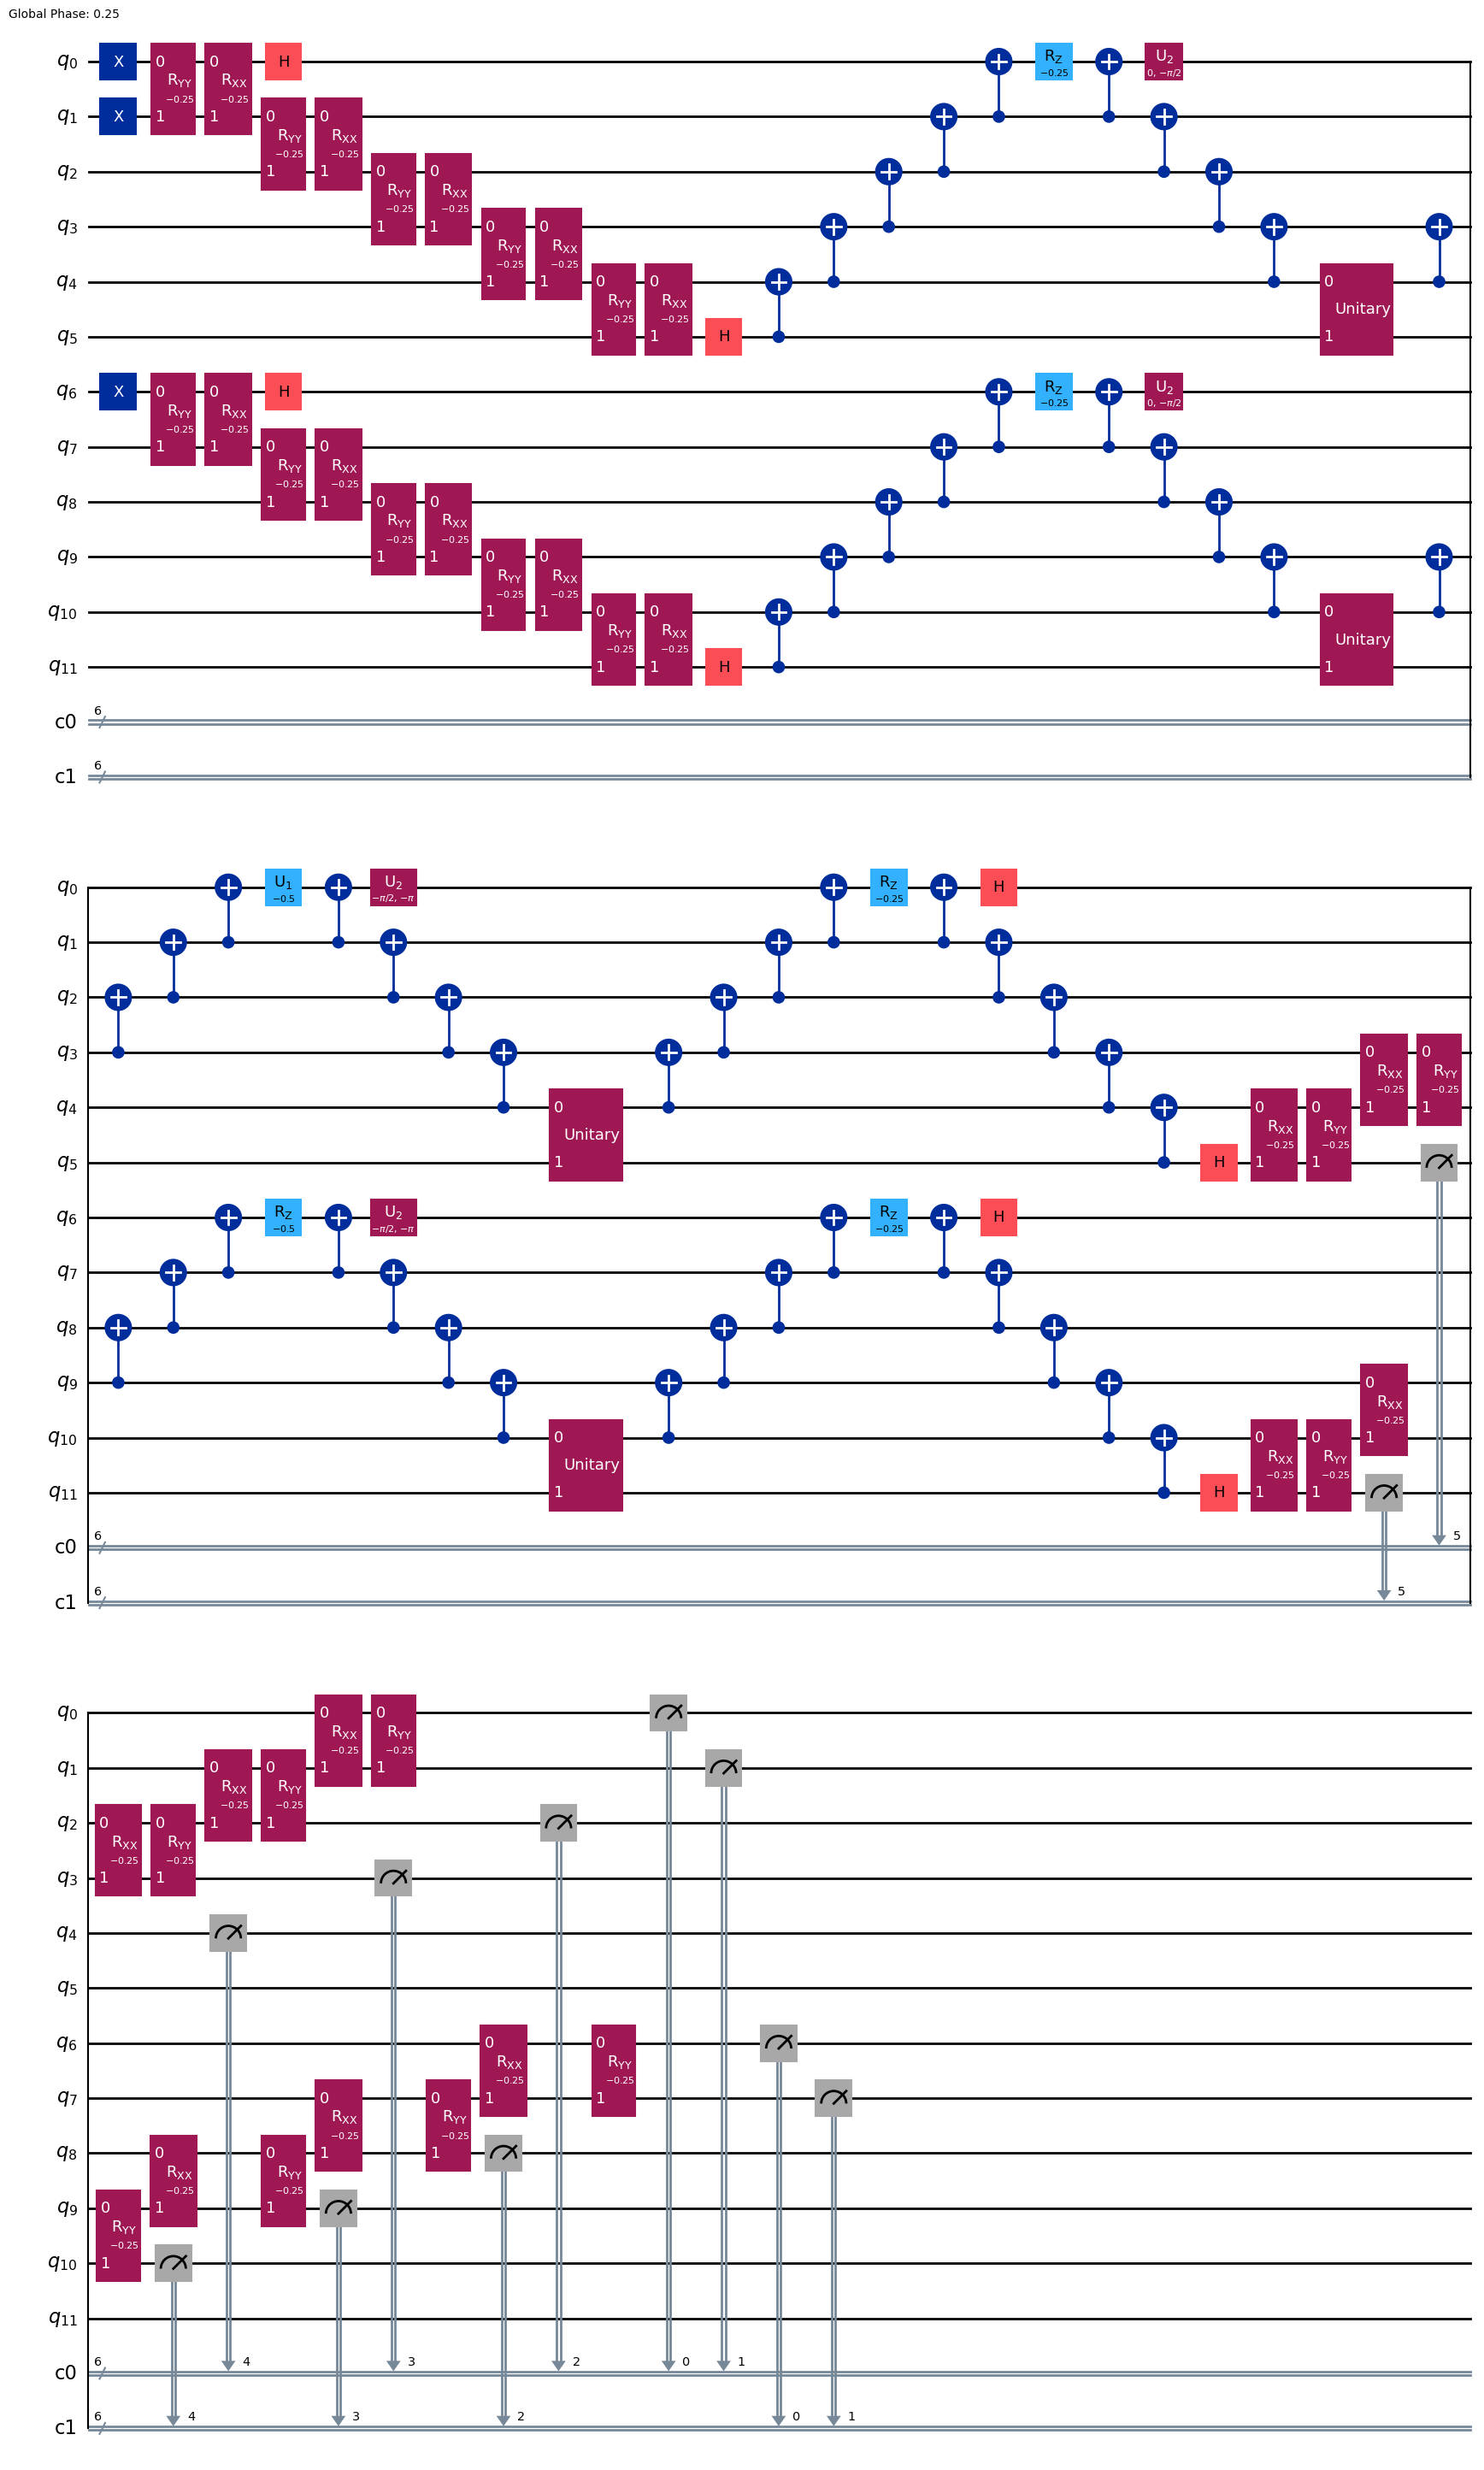

In [13]:
from qiskit_aer import AerSimulator
from qiskit import transpile

simulator = AerSimulator()
shots = 8192
qc = transpile(qc, simulator)
qc.draw(output='mpl')

In [14]:
result = simulator.run(qc, shots=shots).result()
counts = result.get_counts(qc)
print(counts)

{'100000 011000': 1, '000100 001001': 1, '000010 101000': 2, '100000 010010': 18, '000010 010100': 5, '000001 011000': 2, '010000 100100': 1, '100000 000101': 234, '010000 100010': 10, '100000 101000': 5, '001000 000110': 1, '000100 100100': 6, '010000 010010': 1, '000010 001001': 13, '000001 000101': 698, '000001 010100': 8, '100000 010100': 5, '000001 100001': 54, '000100 100010': 12, '010000 000011': 65, '001000 000101': 6, '000010 000110': 19, '000001 010010': 55, '000010 100001': 21, '000010 100100': 69, '100000 100001': 23, '010000 000101': 18, '010000 001001': 3, '010000 000110': 2, '100000 000011': 1052, '000001 101000': 11, '100000 000110': 19, '000001 000110': 39, '000001 001100': 1, '000001 001001': 37, '001000 000011': 12, '000001 100100': 218, '000010 010010': 20, '000100 101000': 1, '000001 100010': 757, '000010 100010': 239, '000100 000101': 22, '000100 000011': 56, '000010 000101': 213, '000010 000011': 844, '010000 100001': 2, '100000 100100': 71, '001000 100010': 4, '